In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
low_contrast_img = cv2.imread("D:\Computer-Vision\Image\data\image\lowcontrast2.jpg")

RGB image.

In [3]:
low_contrast_img_RGB = cv2.cvtColor(low_contrast_img,cv2.COLOR_BGR2RGB)

Gray image.

In [4]:
low_contrast_img_Gray = cv2.cvtColor(low_contrast_img,cv2.COLOR_RGB2GRAY)

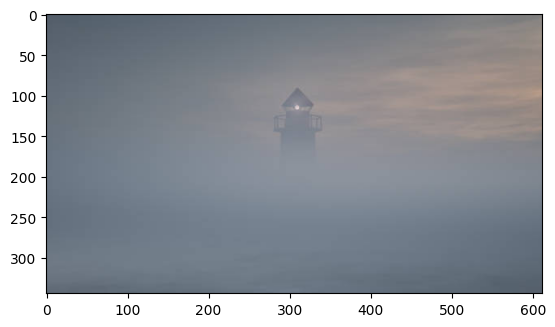

In [5]:
plt.imshow(low_contrast_img_RGB)
plt.show()

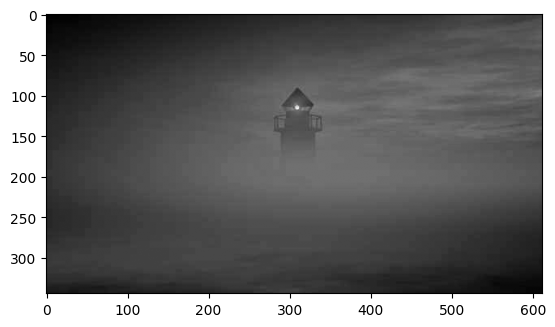

In [6]:
plt.imshow(low_contrast_img_Gray,cmap='gray')
plt.show()

Contrast enhancing by Histogram stertch on Gray image.

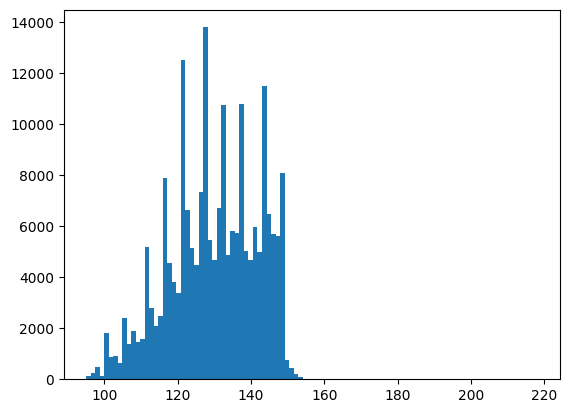

In [7]:
plt.hist(low_contrast_img_Gray.reshape(-1),bins=100)
plt.show()

In [8]:
i_min = low_contrast_img_Gray.min()
i_max = low_contrast_img_Gray.max()

In [9]:
i_min

np.uint8(95)

In [10]:
i_max

np.uint8(218)

255 is a max that I picked.

In [11]:
low_contrast_img_Gray_stretched = (low_contrast_img_Gray - i_min) / (i_max - i_min) * 255

In [12]:
low_contrast_img_Gray_stretched.dtype

dtype('float64')

Its can not be float. Its must be int. Then ...

In [13]:
low_contrast_img_Gray_stretched = low_contrast_img_Gray_stretched.astype('uint8')

In [14]:
low_contrast_img_Gray_stretched.dtype

dtype('uint8')

In [15]:
low_contrast_img_Gray.min()

np.uint8(95)

In [16]:
low_contrast_img_Gray.max()

np.uint8(218)

In [17]:
low_contrast_img_Gray_stretched.min()

np.uint8(0)

In [18]:
low_contrast_img_Gray_stretched.max()

np.uint8(255)

Now we are going to show 2 images.

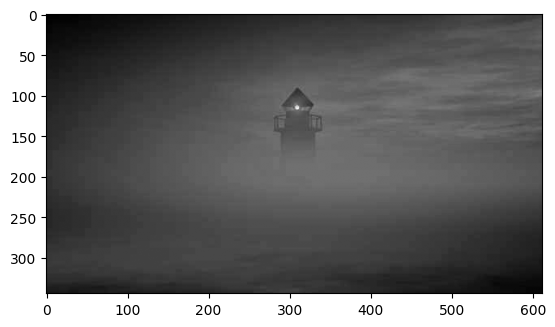

In [19]:
plt.imshow(low_contrast_img_Gray,cmap='gray')
plt.show()

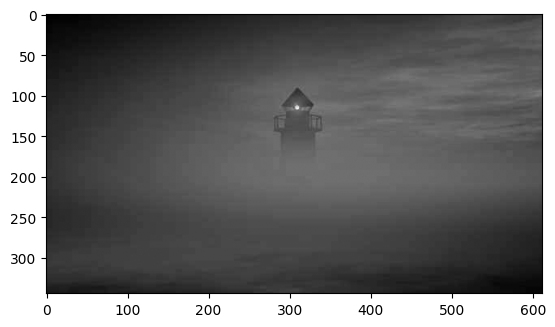

In [20]:
plt.imshow(low_contrast_img_Gray_stretched,cmap='gray')
plt.show()

Not a acceptable work.

Applying the stertching on RGB channels.

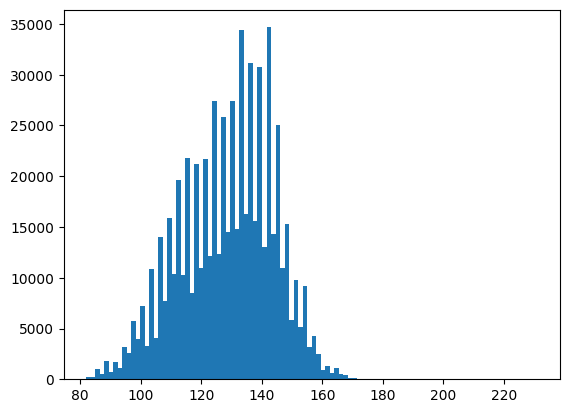

In [21]:
plt.hist(low_contrast_img_RGB.reshape(-1),bins=100)
plt.show()

In [22]:
channel = cv2.split(low_contrast_img_RGB)
stretched_channels = []
for ch in channel:
    i_min = ch.min()
    i_max = ch.max()
    ch_stretched = ((ch - i_min) / (i_max - i_min) * 255).astype('uint8')
    stretched_channels.append(ch_stretched)

rgb_img_stretched = cv2.merge(stretched_channels)

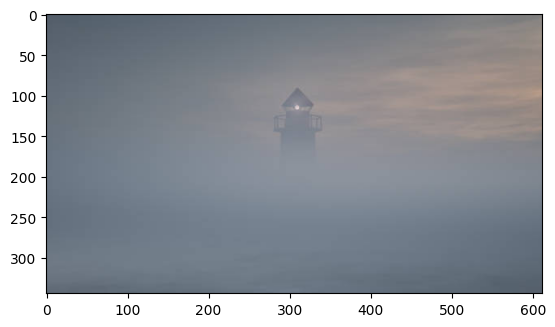

In [23]:
plt.imshow(low_contrast_img_RGB)
plt.show()

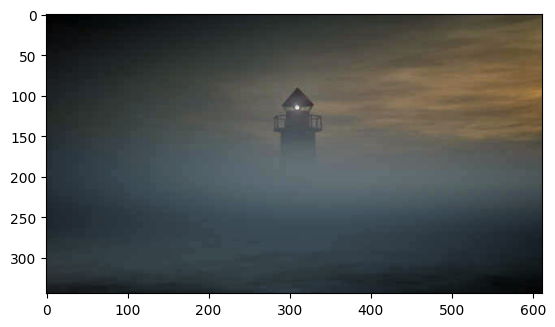

In [24]:
plt.imshow(rgb_img_stretched)
plt.show()

Not the best but its better.

Sometimes it messes up the color combination.

Equalize Histogram

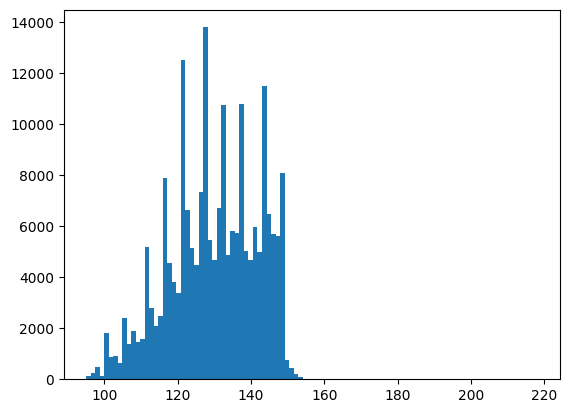

In [25]:
plt.hist(low_contrast_img_Gray.reshape(-1),bins=100)
plt.show()

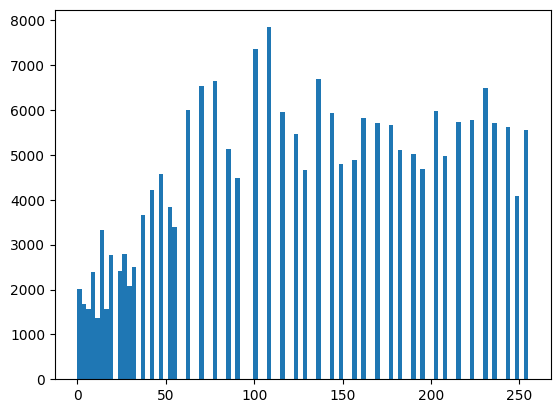

In [26]:
plt.hist(cv2.equalizeHist(low_contrast_img_Gray).reshape(-1),bins=100)
plt.show()

Its trying to equalize and uniform the histogram.

It can support the outlier points like noises.

In [27]:
low_contrast_img_Gray_equ = cv2.equalizeHist(low_contrast_img_Gray)

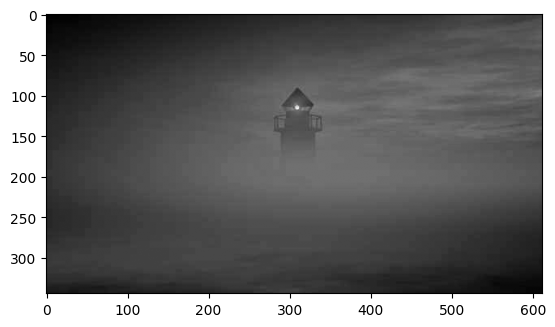

In [28]:
plt.imshow(low_contrast_img_Gray,cmap='gray')
plt.show()

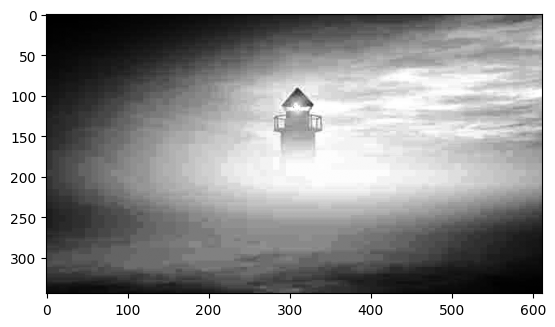

In [29]:
plt.imshow(low_contrast_img_Gray_equ,cmap='gray')
plt.show()

It messes up the color combination.

Now appliying this for Color image.

In [30]:
channel = cv2.split(low_contrast_img_RGB)
equalized_channels = []
for ch in channel:
    ch_equlized = cv2.equalizeHist(ch)
    equalized_channels.append(ch_equlized)

rgb_img_equlized = cv2.merge(equalized_channels)

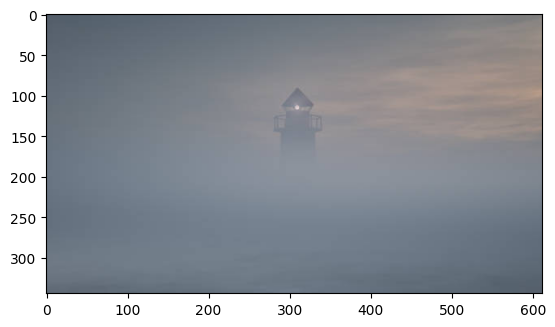

In [31]:
plt.imshow(low_contrast_img_RGB)
plt.show()

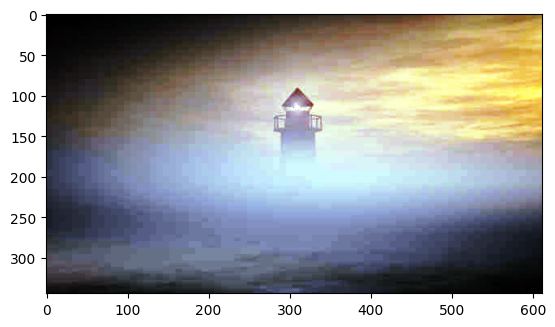

In [32]:
plt.imshow(rgb_img_equlized)
plt.show()

It messes up the color combination more than Gray image.